# PROYECTO DEEP LEARNING

- Origen del dataset:
  
PlantVillage Dataset (disponible en Kaggle).
https://www.kaggle.com/datasets/arjuntejaswi/plant-village

- Tipo de datos:
Imágenes RGB (visión por computadora).
Imágenes formato JPG

- Estructura original:
Múltiples clases de enfermedades por tipo de planta.

Transformación para el proyecto:
Se agrupan todas las enfermedades en una sola clase:
Clase 0: Healthy
Clase 1: Diseased


- Modelo 1 — CNN desde cero

Capas Convolucionales + ReLU

MaxPooling

Dropout

Fully Connected

Capa final con Sigmoid

Modelo 2 — Transfer Learning

Modelo base: ResNet50 preentrenado en ImageNet

Congelamiento parcial de capas

Capa densa final con Sigmoid

Fine-tuning progresivo

Función de pérdida:
Binary Cross Entropy

Optimizador:
Adam

Regularización:

Dropout

Early stopping

Data augmentation


# CLASIFICACIÓN DE CARPETAS

- filepath (ruta completa a la imagen)
- original_class (nombre de carpeta)
- binary_label (0 si contiene “healthy”, 1 si no)
- binary_class (“healthy” o “diseased”
- Calcular conteos y proporciones (EDA de balance).
- Graficar barras

El dataset está organizado en carpetas. Si la carpeta dice “healthy”, esa imagen la consideramos sana; si no, enferma. Luego contamos cuántas hay de cada una para saber si el dataset está balanceado.


In [1]:
import os
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

# Auto-detectar la raíz del repositorio buscando environment.yml
def find_repo_root(start: Path, marker: str = "environment.yml") -> Path:
    for parent in [start, *start.parents]:
        if (parent / marker).exists():
            return parent
    raise FileNotFoundError(f"No se encontró '{marker}' en ningún directorio padre de {start}")

REPO_ROOT = find_repo_root(Path().resolve())
DATA_DIR = REPO_ROOT / "data" / "raw" / "PlantVillage"

print(f"Repo root: {REPO_ROOT}")
print(f"Data dir:  {DATA_DIR}")

# Extensiones comunes de imágenes
IMG_EXTS = {".jpg", ".jpeg", ".png"}

rows = []
for class_dir in DATA_DIR.iterdir():
    if not class_dir.is_dir():
        continue
    original_class = class_dir.name
    # Recorre imágenes dentro de cada carpeta
    for img_path in class_dir.rglob("*"):
        if img_path.suffix.lower() in IMG_EXTS:
            # Regla binaria: si la carpeta contiene "healthy" -> 0, si no -> 1
            is_healthy = "healthy" in original_class.lower()
            binary_label = 0 if is_healthy else 1
            binary_class = "healthy" if is_healthy else "diseased"
            rows.append({
                "filepath": str(img_path),
                "original_class": original_class,
                "binary_label": binary_label,
                "binary_class": binary_class
            })

df = pd.DataFrame(rows)
print("Total de imágenes:", len(df))
print("Total de clases originales (carpetas):", df["original_class"].nunique())
df.head()


Repo root: /Users/antonioesparza/repos/GitHub/plant-disease-classifier
Data dir:  /Users/antonioesparza/repos/GitHub/plant-disease-classifier/data/raw/PlantVillage
Total de imágenes: 20638
Total de clases originales (carpetas): 15


,filepath,original_class,binary_label,binary_class
0,/Users/antonioesparza/repos/GitHub/plant-disea...,Tomato_healthy,0,healthy
1,/Users/antonioesparza/repos/GitHub/plant-disea...,Tomato_healthy,0,healthy
2,/Users/antonioesparza/repos/GitHub/plant-disea...,Tomato_healthy,0,healthy
3,/Users/antonioesparza/repos/GitHub/plant-disea...,Tomato_healthy,0,healthy
4,/Users/antonioesparza/repos/GitHub/plant-disea...,Tomato_healthy,0,healthy


# Balance de Clases 
Conteos y Proporciones 
- Las imágenes están guardadas en :  visualizaciones -> eda 


In [2]:
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

# Auto-detectar la raíz del repositorio (por si no está disponible de la celda anterior)
def find_repo_root(start: Path, marker: str = "environment.yml") -> Path:
    for parent in [start, *start.parents]:
        if (parent / marker).exists():
            return parent
    raise FileNotFoundError(f"No se encontró '{marker}' en ningún directorio padre de {start}")

try:
    REPO_ROOT
except NameError:
    REPO_ROOT = find_repo_root(Path().resolve())

# Ruta de guardado relativa al repositorio
SAVE_DIR = REPO_ROOT / "reports" / "figures" / "eda"
SAVE_DIR.mkdir(parents=True, exist_ok=True)

# Datos
counts = df["binary_class"].value_counts().sort_index()
props = (counts / counts.sum())

# Colores oliva
colors = ["#6B8E23", "#556B2F"]

plt.figure(figsize=(8, 6))
bars = plt.bar(counts.index, counts.values, color=colors)

# Títulos
plt.title("Balance de Clases (Clasificación Binaria)", fontsize=18, fontweight='bold')
plt.xlabel("Clase", fontsize=14, fontweight='bold')
plt.ylabel("Número de imágenes", fontsize=14, fontweight='bold')
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

# Ajuste dinámico para posición de texto
max_height = max(counts.values)

# Porcentajes arriba de cada barra
for i, bar in enumerate(bars):
    height = bar.get_height()
    percentage = props.iloc[i] * 100
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + max_height * 0.02,
        f"{percentage:.1f}%",
        ha='center',
        fontsize=13,
        fontweight='bold'
    )

# Guardar
save_path = SAVE_DIR / "balance_clases_binario_estilizado.png"
plt.tight_layout()
plt.savefig(save_path, dpi=300)
plt.close()
print(f"Gráfica guardada en: {save_path}")


Gráfica guardada en: /Users/antonioesparza/repos/GitHub/plant-disease-classifier/reports/figures/eda/balance_clases_binario_estilizado.png


In [3]:
# Valida detalle de enfermas:
# Filtrar únicamente imágenes enfermas
df_diseased = df[df["binary_class"] == "diseased"]

# Contar imágenes por enfermedad original
disease_counts = (
    df_diseased["original_class"]
    .value_counts()
    .sort_values(ascending=False)
)

# Mostrar resultados
print("Número de enfermedades distintas:", disease_counts.shape[0])
print("\nDistribución de enfermedades:\n")
print(disease_counts)

# Convertir a DataFrame para visualizar mejor
disease_summary = disease_counts.reset_index()
disease_summary.columns = ["disease_class", "num_images"]

# Mostrar primeras filas
display(disease_summary.head(20))



Número de enfermedades distintas: 12

Distribución de enfermedades:

original_class
Tomato__Tomato_YellowLeaf__Curl_Virus          3208
Tomato_Bacterial_spot                          2127
Tomato_Late_blight                             1909
Tomato_Septoria_leaf_spot                      1771
Tomato_Spider_mites_Two_spotted_spider_mite    1676
Tomato__Target_Spot                            1404
Potato___Early_blight                          1000
Tomato_Early_blight                            1000
Potato___Late_blight                           1000
Pepper__bell___Bacterial_spot                   997
Tomato_Leaf_Mold                                952
Tomato__Tomato_mosaic_virus                     373
Name: count, dtype: int64


,disease_class,num_images
0,Tomato__Tomato_YellowLeaf__Curl_Virus,3208
1,Tomato_Bacterial_spot,2127
2,Tomato_Late_blight,1909
3,Tomato_Septoria_leaf_spot,1771
4,Tomato_Spider_mites_Two_spotted_spider_mite,1676
5,Tomato__Target_Spot,1404
6,Potato___Early_blight,1000
7,Tomato_Early_blight,1000
8,Potato___Late_blight,1000
9,Pepper__bell___Bacterial_spot,997


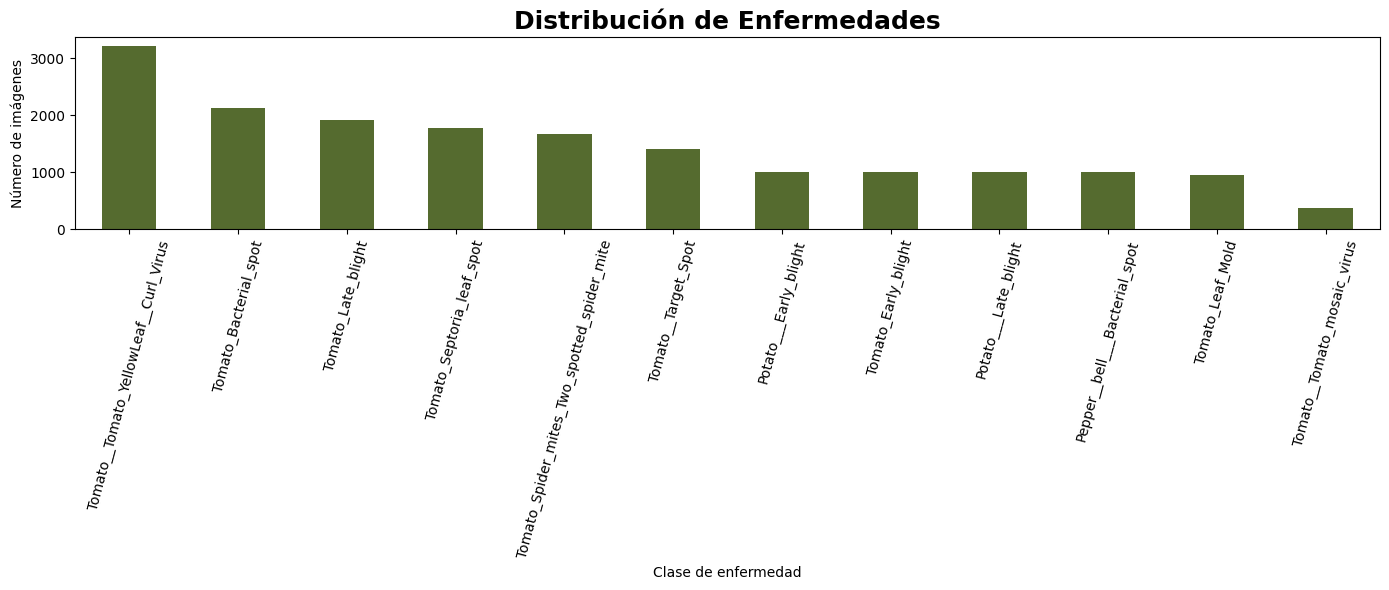

In [4]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,6))

disease_counts.plot(
    kind="bar",
    color="#556B2F"
)

plt.title(
    "Distribución de Enfermedades",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel("Clase de enfermedad")
plt.ylabel("Número de imágenes")

plt.xticks(rotation=75)
plt.tight_layout()

plt.show()

In [5]:
# Carpetas que aportan más imágenes:
top_folders = df["original_class"].value_counts().head(15)
top_folders


original_class
Tomato__Tomato_YellowLeaf__Curl_Virus          3208
Tomato_Bacterial_spot                          2127
Tomato_Late_blight                             1909
Tomato_Septoria_leaf_spot                      1771
Tomato_Spider_mites_Two_spotted_spider_mite    1676
Tomato_healthy                                 1591
Pepper__bell___healthy                         1478
Tomato__Target_Spot                            1404
Potato___Early_blight                          1000
Tomato_Early_blight                            1000
Potato___Late_blight                           1000
Pepper__bell___Bacterial_spot                   997
Tomato_Leaf_Mold                                952
Tomato__Tomato_mosaic_virus                     373
Potato___healthy                                152
Name: count, dtype: int64

In [6]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

# Número máximo de imágenes para análisis
MAX_IMAGES = 1000

# Listas para almacenar canales
all_r = []
all_g = []
all_b = []

# Tomar muestra del dataset
sample_df = df.sample(
    min(MAX_IMAGES, len(df)),
    random_state=42
)

print(f"Procesando {len(sample_df)} imágenes...")

# Recorrer imágenes
for path in tqdm(sample_df["filepath"]):

    # Leer imagen
    img = cv2.imread(path)

    if img is None:
        continue

    # Convertir BGR → RGB
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # Extraer canales
    r = img[:, :, 0].flatten()
    g = img[:, :, 1].flatten()
    b = img[:, :, 2].flatten()

    # Guardar
    all_r.extend(r)
    all_g.extend(g)
    all_b.extend(b)

# Convertir a numpy arrays
all_r = np.array(all_r)
all_g = np.array(all_g)
all_b = np.array(all_b)

print("Análisis completado.")

Procesando 1000 imágenes...


100%|██████████| 1000/1000 [00:05<00:00, 179.15it/s]

Análisis completado.


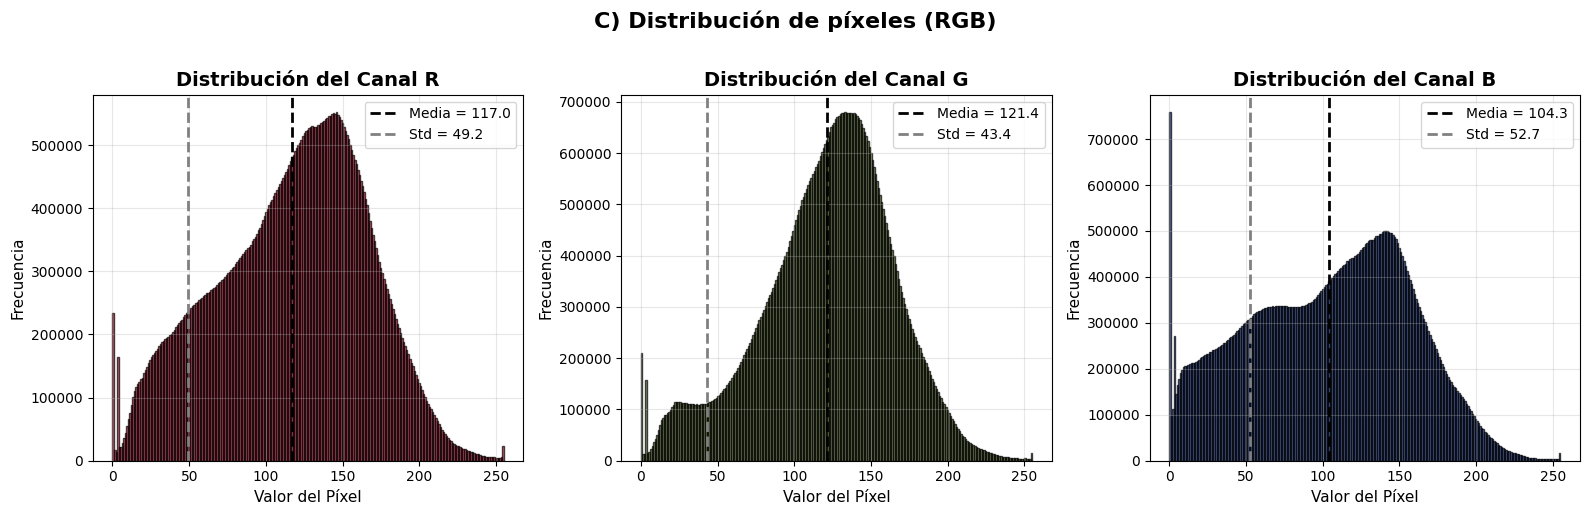

Gráfica RGB guardada en: /Users/antonioesparza/repos/GitHub/plant-disease-classifier/reports/figures/eda/distribucion_rgb.png

=== Estadísticas de Canales ===
Canal R - Media: 116.96, Std: 49.15
Canal G - Media: 121.36, Std: 43.43
Canal B - Media: 104.32, Std: 52.69


In [7]:
# Distribución de píxeles (RGB)
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Histograma Canal R
axes[0].hist(all_r, bins=256, color="#C41E3A", edgecolor="black", alpha=0.7)
axes[0].set_title("Distribución del Canal R", fontsize=14, fontweight="bold")
axes[0].set_xlabel("Valor del Píxel", fontsize=11)
axes[0].set_ylabel("Frecuencia", fontsize=11)
axes[0].axvline(all_r.mean(), color="black", linestyle="--", linewidth=2, label=f"Media = {all_r.mean():.1f}")
axes[0].axvline(all_r.std(), color="gray", linestyle="--", linewidth=2, label=f"Std = {all_r.std():.1f}")
axes[0].legend()
axes[0].grid(alpha=0.3)

# Histograma Canal G
axes[1].hist(all_g, bins=256, color="#556B2F", edgecolor="black", alpha=0.7)
axes[1].set_title("Distribución del Canal G", fontsize=14, fontweight="bold")
axes[1].set_xlabel("Valor del Píxel", fontsize=11)
axes[1].set_ylabel("Frecuencia", fontsize=11)
axes[1].axvline(all_g.mean(), color="black", linestyle="--", linewidth=2, label=f"Media = {all_g.mean():.1f}")
axes[1].axvline(all_g.std(), color="gray", linestyle="--", linewidth=2, label=f"Std = {all_g.std():.1f}")
axes[1].legend()
axes[1].grid(alpha=0.3)

# Histograma Canal B
axes[2].hist(all_b, bins=256, color="#1E3A8A", edgecolor="black", alpha=0.7)
axes[2].set_title("Distribución del Canal B", fontsize=14, fontweight="bold")
axes[2].set_xlabel("Valor del Píxel", fontsize=11)
axes[2].set_ylabel("Frecuencia", fontsize=11)
axes[2].axvline(all_b.mean(), color="black", linestyle="--", linewidth=2, label=f"Media = {all_b.mean():.1f}")
axes[2].axvline(all_b.std(), color="gray", linestyle="--", linewidth=2, label=f"Std = {all_b.std():.1f}")
axes[2].legend()
axes[2].grid(alpha=0.3)

plt.suptitle("C) Distribución de píxeles (RGB)", fontsize=16, fontweight="bold", y=1.02)
plt.tight_layout()

# Guardar
rgb_save_path = SAVE_DIR / "distribucion_rgb.png"
plt.savefig(rgb_save_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"Gráfica RGB guardada en: {rgb_save_path}")
print("\n=== Estadísticas de Canales ===")
print(f"Canal R - Media: {all_r.mean():.2f}, Std: {all_r.std():.2f}")
print(f"Canal G - Media: {all_g.mean():.2f}, Std: {all_g.std():.2f}")
print(f"Canal B - Media: {all_b.mean():.2f}, Std: {all_b.std():.2f}")


Procesando 1000 imágenes...


100%|██████████| 1000/1000 [00:06<00:00, 144.98it/s]


Extracción completada.


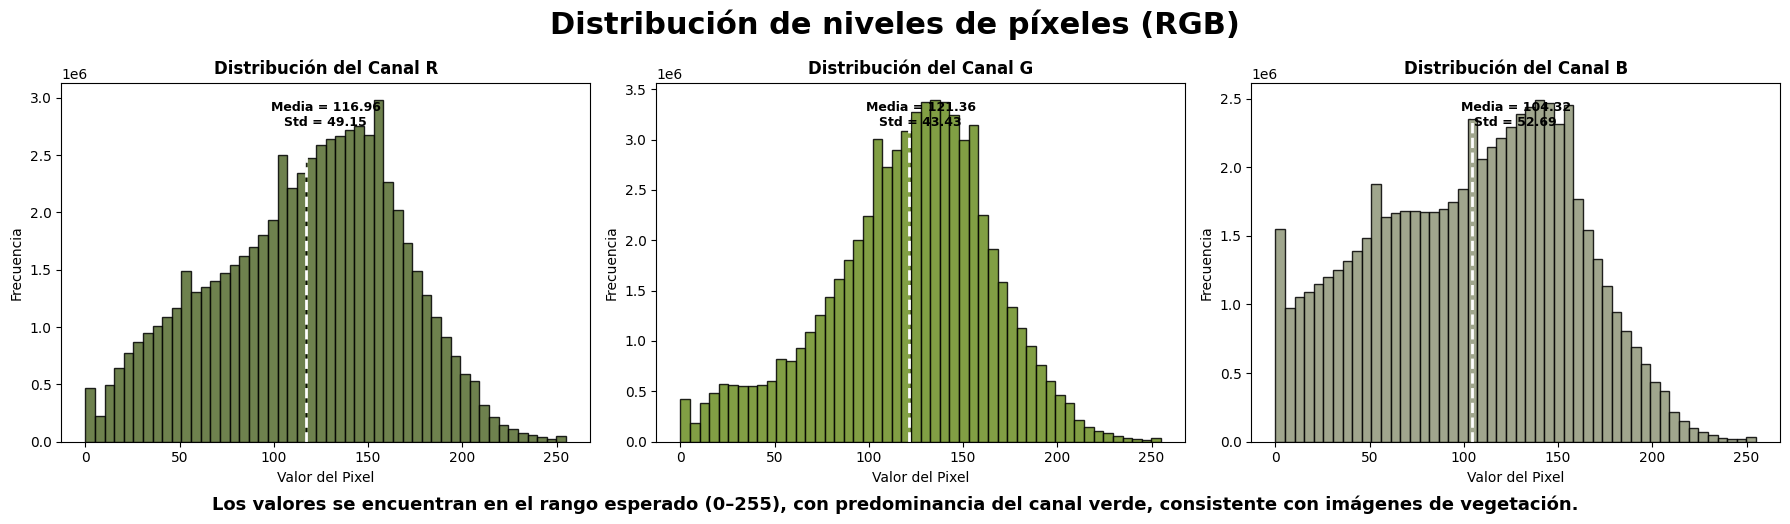

Figura guardada en:
/Users/antonioesparza/repos/GitHub/plant-disease-classifier/reports/figures/eda/rgb_pixel_distribution.png


In [8]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

# ==========================================
# CONFIGURACIÓN
# ==========================================

MAX_IMAGES = 1000  # cantidad máxima de imágenes a analizar

# Muestreo del dataset
sample_df = df.sample(
    min(MAX_IMAGES, len(df)),
    random_state=42
)

# ==========================================
# EXTRAER PIXELES RGB
# ==========================================

all_r = []
all_g = []
all_b = []

print(f"Procesando {len(sample_df)} imágenes...")

for path in tqdm(sample_df["filepath"]):

    # Leer imagen
    img = cv2.imread(path)

    if img is None:
        continue

    # Convertir BGR -> RGB
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # Extraer canales
    r = img[:, :, 0].flatten()
    g = img[:, :, 1].flatten()
    b = img[:, :, 2].flatten()

    all_r.extend(r)
    all_g.extend(g)
    all_b.extend(b)

# Convertir a arrays numpy
all_r = np.array(all_r)
all_g = np.array(all_g)
all_b = np.array(all_b)

print("Extracción completada.")

# ==========================================
# CALCULAR ESTADÍSTICAS
# ==========================================

stats = {
    "R": (np.mean(all_r), np.std(all_r)),
    "G": (np.mean(all_g), np.std(all_g)),
    "B": (np.mean(all_b), np.std(all_b)),
}

# ==========================================
# CREAR FIGURA
# ==========================================

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

channels = [
    ("R", all_r, "#556B2F"),
    ("G", all_g, "#6B8E23"),
    ("B", all_b, "#8F9779"),
]

for ax, (name, values, color) in zip(axes, channels):

    mean, std = stats[name]

    # Histograma
    ax.hist(
        values,
        bins=50,
        color=color,
        edgecolor="black",
        alpha=0.85
    )

    # Línea media
    ax.axvline(
        mean,
        color="white",
        linestyle="--",
        linewidth=2
    )

    # Título
    ax.set_title(
        f"Distribución del Canal {name}",
        fontsize=12,
        fontweight="bold"
    )

    # Etiquetas
    ax.set_xlabel("Valor del Pixel")
    ax.set_ylabel("Frecuencia")

    # Texto estadísticas
    ax.text(
        0.5,
        0.88,
        f"Media = {mean:.2f}\nStd = {std:.2f}",
        transform=ax.transAxes,
        ha="center",
        fontsize=9,
        fontweight="bold"
    )

# ==========================================
# TÍTULO GENERAL
# ==========================================

fig.suptitle(
    "Distribución de niveles de píxeles (RGB)",
    fontsize=22,
    fontweight="bold"
)

# ==========================================
# TEXTO INFERIOR
# ==========================================

fig.text(
    0.5,
    -0.02,
    "Los valores se encuentran en el rango esperado (0–255), "
    "con predominancia del canal verde, consistente con imágenes de vegetación.",
    ha="center",
    fontsize=13,
    fontweight="bold"
)

plt.tight_layout()

# ==========================================
# GUARDAR FIGURA
# ==========================================

SAVE_DIR = REPO_ROOT / "reports" / "figures" / "eda"
SAVE_DIR.mkdir(parents=True, exist_ok=True)

save_path = SAVE_DIR / "rgb_pixel_distribution.png"

plt.savefig(
    save_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(f"Figura guardada en:\n{save_path}")

In [9]:
# VALIDAR EL TAMAÑO DE LAS IMAGENES
import cv2
import pandas as pd
from tqdm import tqdm

# ==========================================
# VALIDACIÓN DE IMÁGENES
# ==========================================

expected_shape = (224, 224, 3)

invalid_images = []

print("Validando dimensiones de imágenes...")

for path in tqdm(df["filepath"]):

    try:
        # Leer imagen
        img = cv2.imread(path)

        # Verificar lectura
        if img is None:
            invalid_images.append({
                "filepath": path,
                "error": "No se pudo leer"
            })
            continue

        # Convertir BGR -> RGB
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        # Obtener shape
        shape = img.shape

        # Validar dimensiones
        if shape != expected_shape:
            invalid_images.append({
                "filepath": path,
                "shape": shape
            })

    except Exception as e:
        invalid_images.append({
            "filepath": path,
            "error": str(e)
        })

# ==========================================
# RESULTADOS
# ==========================================

invalid_df = pd.DataFrame(invalid_images)

print("\n===================================")
print("VALIDACIÓN COMPLETADA")
print("===================================")

print(f"Total imágenes revisadas: {len(df)}")
print(f"Imágenes inválidas: {len(invalid_df)}")

if len(invalid_df) > 0:
    display(invalid_df.head())
else:
    print("✅ Todas las imágenes tienen shape 224x224x3")

Validando dimensiones de imágenes...


100%|██████████| 20638/20638 [00:10<00:00, 1892.95it/s]


VALIDACIÓN COMPLETADA
Total imágenes revisadas: 20638
Imágenes inválidas: 20638


,filepath,shape
0,/Users/antonioesparza/repos/GitHub/plant-disea...,"(256, 256, 3)"
1,/Users/antonioesparza/repos/GitHub/plant-disea...,"(256, 256, 3)"
2,/Users/antonioesparza/repos/GitHub/plant-disea...,"(256, 256, 3)"
3,/Users/antonioesparza/repos/GitHub/plant-disea...,"(256, 256, 3)"
4,/Users/antonioesparza/repos/GitHub/plant-disea...,"(256, 256, 3)"


## Resize dataset 224x224x3

In [10]:
import cv2
from pathlib import Path
from tqdm import tqdm

# ==========================================
# DIRECTORIOS
# ==========================================

RAW_DIR = REPO_ROOT / "data" / "raw" / "PlantVillage"
PROCESSED_DIR = REPO_ROOT / "data" / "processed" / "PlantVillage_224"

PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

# ==========================================
# RESIZE + GUARDADO
# ==========================================

print("Procesando imágenes...")

for class_dir in tqdm(list(RAW_DIR.iterdir())):

    if not class_dir.is_dir():
        continue

    # Crear carpeta equivalente
    output_class_dir = PROCESSED_DIR / class_dir.name
    output_class_dir.mkdir(parents=True, exist_ok=True)

    # Recorrer imágenes
    for img_path in class_dir.rglob("*"):

        if img_path.suffix.lower() not in {".jpg", ".jpeg", ".png"}:
            continue

        # Leer imagen
        img = cv2.imread(str(img_path))

        if img is None:
            continue

        # Convertir BGR -> RGB
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        # Resize
        img = cv2.resize(img, (224, 224))

        # Convertir RGB -> BGR para guardar con OpenCV
        img = cv2.cvtColor(img, cv2.COLOR_RGB2BGR)

        # Ruta de salida
        output_path = output_class_dir / img_path.name

        # Guardar imagen
        cv2.imwrite(str(output_path), img)

print("\n✅ Imágenes procesadas y guardadas.")
print(f"📂 Ruta: {PROCESSED_DIR}")

Procesando imágenes...


100%|██████████| 16/16 [00:20<00:00,  1.26s/it]


✅ Imágenes procesadas y guardadas.
📂 Ruta: /Users/antonioesparza/repos/GitHub/plant-disease-classifier/data/processed/PlantVillage_224


## Valida Resize del dataset para cumplir (224 x 224 x3)

In [11]:
import cv2
import pandas as pd
from pathlib import Path
from tqdm import tqdm

# ==========================================
# CONFIGURACIÓN
# ==========================================

PROCESSED_DIR = REPO_ROOT / "data" / "processed" / "PlantVillage_224"
expected_shape = (224, 224, 3)

# ==========================================
# VALIDACIÓN DE IMÁGENES PROCESADAS
# ==========================================

print(f"Validando imágenes en: {PROCESSED_DIR}")
print("=" * 60)

# Recopilar todas las imágenes (todas las variaciones de extensión)
IMG_EXTS = {".jpg", ".JPG", ".jpeg", ".JPEG", ".png", ".PNG"}
image_paths = [p for p in PROCESSED_DIR.rglob("*") if p.suffix in IMG_EXTS]

print(f"Total de imágenes encontradas: {len(image_paths)}")

if len(image_paths) == 0:
    print("⚠️ No se encontraron imágenes en la ruta especificada")
else:
    # Validación rápida: solo leer header con PIL (sin cargar píxeles)
    from PIL import Image

    invalid_images = []
    valid_count = 0

    print("\nValidando (modo rápido — solo headers)...")

    for img_path in tqdm(image_paths):
        try:
            with Image.open(img_path) as img:
                w, h = img.size
                mode = img.mode
                if (h, w) != (expected_shape[0], expected_shape[1]):
                    invalid_images.append({
                        "filepath": str(img_path),
                        "shape": (h, w, len(img.getbands())),
                        "expected": expected_shape
                    })
                else:
                    valid_count += 1
        except Exception as e:
            invalid_images.append({"filepath": str(img_path), "error": str(e)})

    print("\n" + "=" * 60)
    print("VALIDACIÓN COMPLETADA")
    print("=" * 60)
    print(f"✅ Imágenes válidas (224x224): {valid_count}")
    print(f"❌ Imágenes inválidas:         {len(invalid_images)}")
    print(f"📊 Total:                      {len(image_paths)}")
    pct_valid = (valid_count / len(image_paths) * 100) if len(image_paths) > 0 else 0
    print(f"🎯 Tasa de éxito:              {pct_valid:.2f}%")

    if len(invalid_images) > 0:
        print("\n⚠️ Imágenes problemáticas (primeras 10):")
        display(pd.DataFrame(invalid_images).head(10))
    else:
        print("\n✅ ¡TODAS LAS IMÁGENES CUMPLEN EL ESTÁNDAR 224x224x3!")


Validando imágenes en: /Users/antonioesparza/repos/GitHub/plant-disease-classifier/data/processed/PlantVillage_224
Total de imágenes encontradas: 20638

Validando (modo rápido — solo headers)...


100%|██████████| 20638/20638 [00:02<00:00, 9502.82it/s] 


VALIDACIÓN COMPLETADA
✅ Imágenes válidas (224x224): 20638
❌ Imágenes inválidas:         0
📊 Total:                      20638
🎯 Tasa de éxito:              100.00%

✅ ¡TODAS LAS IMÁGENES CUMPLEN EL ESTÁNDAR 224x224x3!


## Split del dataset

In [12]:
import pandas as pd
from pathlib import Path
from sklearn.model_selection import train_test_split

# ==========================================
# CONSTRUIR DATAFRAME DESDE PlantVillage_224
# ==========================================

PROCESSED_DIR = REPO_ROOT / "data" / "processed" / "PlantVillage_224"
IMG_EXTS = {".jpg", ".JPG", ".jpeg", ".JPEG", ".png", ".PNG"}

rows = []
for class_dir in PROCESSED_DIR.iterdir():
    if not class_dir.is_dir():
        continue
    original_class = class_dir.name
    for img_path in class_dir.iterdir():
        if img_path.suffix in IMG_EXTS:
            is_healthy = "healthy" in original_class.lower()
            rows.append({
                "filepath": str(img_path),
                "original_class": original_class,
                "binary_label": 0 if is_healthy else 1,
                "binary_class": "healthy" if is_healthy else "diseased"
            })

df_processed = pd.DataFrame(rows)
print(f"Total imágenes en PlantVillage_224: {len(df_processed)}")

# ==========================================
# TRAIN / TEMP SPLIT  (70% / 30%)
# ==========================================

train_df, temp_df = train_test_split(
    df_processed,
    test_size=0.30,
    stratify=df_processed["binary_label"],
    random_state=42
)

# ==========================================
# VALIDATION / TEST SPLIT  (15% / 15%)
# ==========================================

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df["binary_label"],
    random_state=42
)

# ==========================================
# RESULTADOS
# ==========================================

total = len(df_processed)
print(f"\nTrain:      {len(train_df):>6}  ({len(train_df)/total*100:.1f}%)")
print(f"Validation: {len(val_df):>6}  ({len(val_df)/total*100:.1f}%)")
print(f"Test:       {len(test_df):>6}  ({len(test_df)/total*100:.1f}%)")

# ==========================================
# GUARDAR SPLITS EN data/splits/
# ==========================================

SPLITS_DIR = REPO_ROOT / "data" / "splits"
SPLITS_DIR.mkdir(parents=True, exist_ok=True)

train_df.to_csv(SPLITS_DIR / "train.csv", index=False)
val_df.to_csv(SPLITS_DIR / "val.csv", index=False)
test_df.to_csv(SPLITS_DIR / "test.csv", index=False)

print(f"\n✅ Splits guardados en: {SPLITS_DIR}")
print(f"   train.csv  → {len(train_df)} imágenes")
print(f"   val.csv    → {len(val_df)} imágenes")
print(f"   test.csv   → {len(test_df)} imágenes")


Total imágenes en PlantVillage_224: 20638

Train:       14446  (70.0%)
Validation:   3096  (15.0%)
Test:         3096  (15.0%)

✅ Splits guardados en: /Users/antonioesparza/repos/GitHub/plant-disease-classifier/data/splits
   train.csv  → 14446 imágenes
   val.csv    → 3096 imágenes
   test.csv   → 3096 imágenes
